# MNIST Digit Classification in Delay Space

This notebook trains a convolutional neural network that operates **entirely in delay space**
using the temporal arithmetic framework from *Energy Efficient Convolutions with Temporal
Arithmetic* (Gretsch et al., ASPLOS '24).

**Key idea:** values are encoded as delays via `x' = -ln(x)`. Multiplication becomes delay
addition, and addition becomes the negative log-sum-exponential (nLSE). Negative numbers use
split-value representation `<x_pos, x_neg>` (paper Section 2.2).

The network uses custom `TemporalConv2d`, `TemporalLinear`, `TemporalReLU`, and
`TemporalMaxPool2d` layers that implement these delay-space operations.

In [8]:
import sys, os, time
sys.path.insert(0, os.path.abspath(".."))

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from models.temporal_layers import (
    SplitValue, DelayEncoder, DelayDecoder,
    TemporalConv2d, TemporalLinear, TemporalReLU,
    TemporalMaxPool2d, TemporalFlatten, TemporalDropout,
    TemporalSequential,
)

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")
print(f"Using device: {device}")

Using device: mps


## 1. Load MNIST Data

Load from the CSV files in `../datasets/mnist/`. Pixels are normalised to `[0, 1]`
so they map directly to importance space, with a small floor to avoid `ln(0)`.

In [9]:
train_df = pd.read_csv("../datasets/mnist/train.csv")
data = train_df.values
np.random.shuffle(data)

VAL_SPLIT = 2000

X_all = data[:, 1:].astype(np.float32) / 255.0
y_all = data[:, 0].astype(np.int64)

X_val, y_val = X_all[:VAL_SPLIT], y_all[:VAL_SPLIT]
X_train, y_train = X_all[VAL_SPLIT:], y_all[VAL_SPLIT:]

X_train_t = torch.tensor(X_train).reshape(-1, 1, 28, 28)
y_train_t = torch.tensor(y_train)
X_val_t = torch.tensor(X_val).reshape(-1, 1, 28, 28)
y_val_t = torch.tensor(y_val)

print(f"Train: {X_train_t.shape}, Val: {X_val_t.shape}")
print(f"Label distribution (train): {np.bincount(y_train)}")

Train: torch.Size([40000, 1, 28, 28]), Val: torch.Size([2000, 1, 28, 28])
Label distribution (train): [3914 4452 3968 4139 3898 3599 3955 4211 3874 3990]


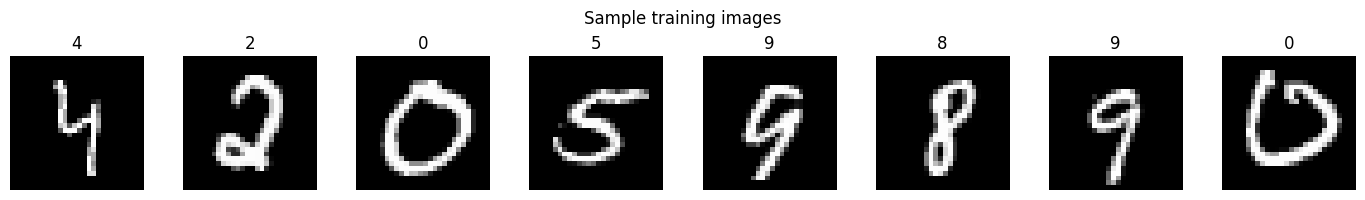

In [10]:
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train_t[i, 0], cmap="gray")
    ax.set_title(f"{y_train_t[i].item()}")
    ax.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()

## 2. Temporal CNN Architecture

```
DelayEncoder
  -> TemporalConv2d(1, 8, 3, padding=1) -> TemporalReLU -> TemporalMaxPool2d(2)
  -> TemporalConv2d(8, 16, 3, padding=1) -> TemporalReLU -> TemporalMaxPool2d(2)
  -> TemporalFlatten
  -> TemporalLinear(16*7*7, 64) -> TemporalReLU
  -> TemporalLinear(64, 10)
-> DelayDecoder -> CrossEntropyLoss
```

All internal operations use the exact nLSE (via `logsumexp`) for smooth
gradient flow. The encoder/decoder convert between importance space and
delay space at the boundaries.

In [11]:
class TemporalMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = DelayEncoder()
        self.features = TemporalSequential(
            TemporalConv2d(1, 8, 3, padding=1),
            TemporalReLU(),
            TemporalMaxPool2d(2),
            TemporalConv2d(8, 16, 3, padding=1),
            TemporalReLU(),
            TemporalMaxPool2d(2),
        )
        self.classifier = TemporalSequential(
            TemporalFlatten(),
            TemporalLinear(16 * 7 * 7, 64),
            TemporalReLU(),
            TemporalLinear(64, 10),
        )
        self.decoder = DelayDecoder()

    def forward(self, x):
        sv = self.encoder(x)
        sv = self.features(sv)
        sv = self.classifier(sv)
        return self.decoder(sv)

model = TemporalMNIST().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

# Quick forward pass sanity check
with torch.no_grad():
    sample = X_train_t[:4].to(device)
    out = model(sample)
    print(f"Forward pass shape: {out.shape}")
    print(f"Sample output: {out[0].cpu().numpy().round(2)}")

Model parameters: 52,138
Forward pass shape: torch.Size([4, 10])
Sample output: [-54.22 -48.72   4.44   5.9  -27.87  13.64 -44.17 -35.8   29.22   6.56]


## 3. Training Loop

In [12]:
EPOCHS = 3
BATCH_SIZE = 64
LR = 3e-4
GRAD_CLIP = 5.0

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

history = {"train_loss": [], "val_loss": [], "val_acc": []}

In [13]:
@torch.no_grad()
def evaluate(model, X, y, batch_size=256):
    model.eval()
    ds = torch.utils.data.TensorDataset(X, y)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size)
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * yb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    return total_loss / total, correct / total

In [14]:
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val Acc':>8} | {'Time':>6}")
print("-" * 56)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)

        if torch.isnan(loss):
            print(f"  NaN loss at epoch {epoch}, skipping batch")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        epoch_loss += loss.item() * yb.size(0)

    train_loss = epoch_loss / len(train_ds)
    val_loss, val_acc = evaluate(model, X_val_t, y_val_t)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - t0
    print(f"{epoch:5d} | {train_loss:10.4f} | {val_loss:10.4f} | {val_acc:7.2%} | {elapsed:5.1f}s")

Epoch | Train Loss |   Val Loss |  Val Acc |   Time
--------------------------------------------------------
    1 |     3.7524 |     0.4489 |  86.65% |  80.8s
    2 |     0.4116 |     0.3817 |  88.60% |  78.1s
    3 |     0.3698 |     0.3202 |  90.00% |  76.5s


## 4. Training Curves

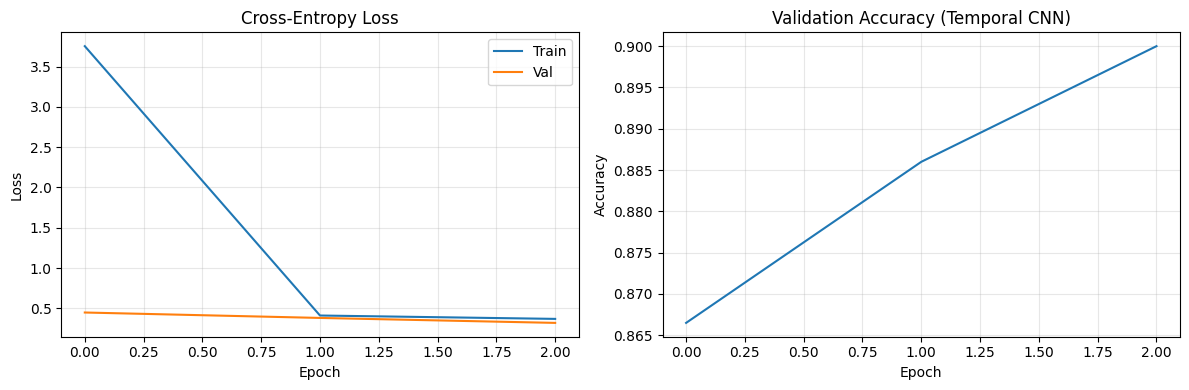


Best validation accuracy: 90.00%


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Cross-Entropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["val_acc"])
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy (Temporal CNN)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest validation accuracy: {max(history['val_acc']):.2%}")

## 5. Prediction Examples

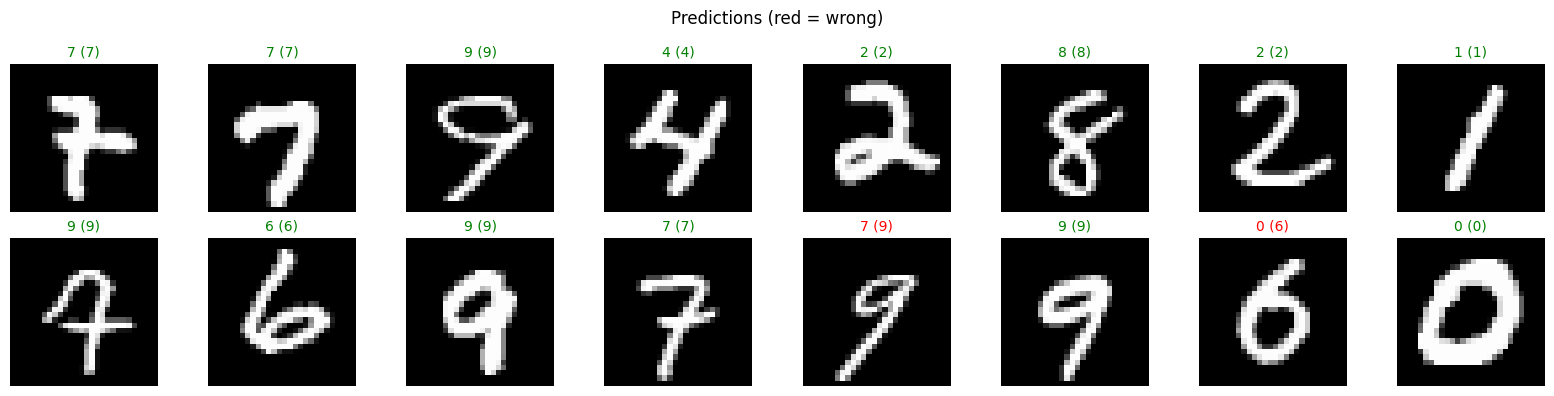

In [16]:
model.eval()
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
indices = np.random.choice(len(X_val_t), 16, replace=False)

with torch.no_grad():
    for i, idx in enumerate(indices):
        ax = axes[i // 8, i % 8]
        img = X_val_t[idx]
        label = y_val_t[idx].item()
        logit = model(img.unsqueeze(0).to(device))
        pred = logit.argmax(1).item()
        ax.imshow(img[0], cmap="gray")
        colour = "green" if pred == label else "red"
        ax.set_title(f"{pred} ({label})", color=colour, fontsize=10)
        ax.axis("off")

plt.suptitle("Predictions (red = wrong)")
plt.tight_layout()
plt.show()

## 6. Baseline: Standard PyTorch CNN

Same architecture but using ordinary `nn.Conv2d` and `nn.Linear` for comparison.

In [17]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 64), nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

baseline = BaselineCNN().to(device)
opt_b = optim.Adam(baseline.parameters(), lr=1e-3)
hist_b = {"val_acc": []}

bl_train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)

for epoch in range(1, 11):
    baseline.train()
    for xb, yb in bl_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_b.zero_grad()
        loss = criterion(baseline(xb), yb)
        loss.backward()
        opt_b.step()
    _, acc = evaluate(baseline, X_val_t, y_val_t)
    hist_b["val_acc"].append(acc)
    print(f"Baseline epoch {epoch:2d}  val acc {acc:.2%}")

print(f"\nBaseline best: {max(hist_b['val_acc']):.2%}")

Baseline epoch  1  val acc 94.70%
Baseline epoch  2  val acc 97.05%
Baseline epoch  3  val acc 97.40%
Baseline epoch  4  val acc 98.20%
Baseline epoch  5  val acc 98.35%
Baseline epoch  6  val acc 98.10%
Baseline epoch  7  val acc 98.55%
Baseline epoch  8  val acc 98.60%
Baseline epoch  9  val acc 98.75%
Baseline epoch 10  val acc 98.65%

Baseline best: 98.75%


## 7. Comparison

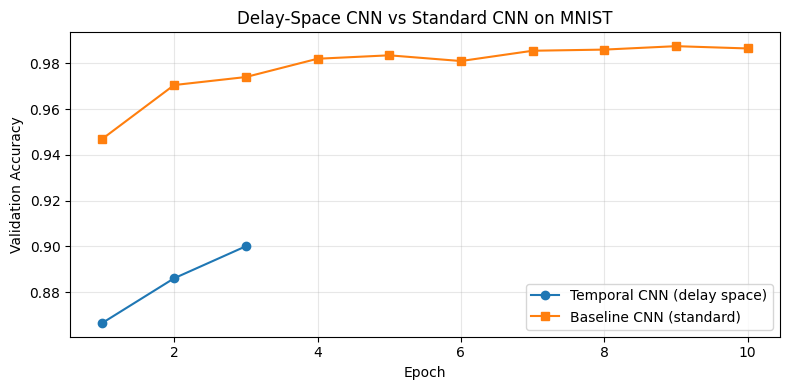

Temporal CNN best accuracy:  90.00%
Baseline CNN best accuracy:  98.75%


In [18]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history['val_acc']) + 1), history['val_acc'],
         marker='o', label='Temporal CNN (delay space)')
plt.plot(range(1, len(hist_b['val_acc']) + 1), hist_b['val_acc'],
         marker='s', label='Baseline CNN (standard)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Delay-Space CNN vs Standard CNN on MNIST')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Temporal CNN best accuracy:  {max(history['val_acc']):.2%}")
print(f"Baseline CNN best accuracy:  {max(hist_b['val_acc']):.2%}")